# 05 · Beklenti, Varyans ve Sihirli Özellikleri
**Probability Lab** · Makine Öğrenmesinin Temel Taşı

---
> **Bu notebook'ta ne öğreneceğiz?**  
> Bütün istatistik, makine öğrenmesi algoritmaları, portföy yönetimi ve hata fonksiyonları (Loss Functions) temelde birkaç beklenti (Expectation) ve varyans kuralı üzerine kuruludur.  
> Bu kurallar o kadar önemlidir ki, "Matematiğin sihri" diyebiliriz:
> - $E[X+Y]$ her zaman $E[X] + E[Y]$'ye eşittir (Değişkenler ne kadar bağımlı olsa bile!).
> - Portföy riskini hesaplamaktan, modellerin Bias-Variance Tradeoff'una kadar her şey bu özelliklerden türer.

**Önkoşul:** Kovaryans ve Korelasyon (04b)  
**Veri:**  
- `student-mat.csv` (UCI) — Öğrenci performans ve sınav verileri  
- `yfinance` — Gerçek borsa verileri (Portföy Varyansı için)  
- `california_housing` (sklearn) — Hata Karesi Beklentisi (MSE) için  
**Araçlar:** Python (pandas, yfinance), R, SQL (DuckDB)

---
## 1 · Teorik Temeller: Formülleri Formül Yapan Kurallar

Beklenen değer (Expectation $E[X]$) aslında bir nevi ağırlıklı ortalamadır. Varyans ($Var(X)$) ise o ortalamadan ne kadar saptığımızın ölçüsüdür.

### 1.1 Beklentinin Lineerliği (Linearity of Expectation) — 🥇 EN ÖNEMLİ KURAL

İster bağımsız olsunlar, ister birbirlerine sımsıkı bağlı olsunlar; iki şeyin toplamının beklenen değeri, beklenen değerlerinin toplamına eşittir.

$$E[X + Y] = E[X] + E[Y]$$

Eğer bir değişkene sabit ekler veya sabit ile çarparsak:
$$E[aX + b] = aE[X] + b$$

### 1.2 Varyansın Özellikleri

Varyans lineer DEĞİLDİR. Yayılım (dağılımın genişliği) ölçtüğü için çok farklı tepki verir.

Bir veriye sabit sayı eklemek (herkesin maaşına 5000 TL zam) varyansı ETKİLEMEZ (herkes birlikte kayar):
$$Var(X + c) = Var(X)$$

Bir veriyi sabit sayı ile çarpmak (maaşlara %50 zam, yani 1.5 katı) varyansı **Karesi** kadar büyütür:
$$Var(aX) = a^2 \cdot Var(X)$$

İki değişkeni topladığımızda varyansları:
$$Var(X + Y) = Var(X) + Var(Y) + 2Cov(X, Y)$$
Eğer $X$ ve $Y$ bağımsızsa ($Cov=0$) bu formül doğrudan $Var(X) + Var(Y)$ olur.

---

### 1.3 Hesaplama Kısayolu: Varyansın Açılımı 

Yukarıdaki $Var(X)=E[(X-\mu)^2]$ tanımı kavramsal olarak doğru ama pratikte elle/kodla hesaplarken kullanışsız — her veri noktası için önce ortalamayı çıkarıp kareye almak gerekiyor. Cebirsel olarak açarsan çok daha pratik bir kısayol çıkıyor:

$$Var(X) = E[(X-\mu)^2] = E[X^2] - (E[X])^2$$

**Kısa türetimi:**
$$E[(X-\mu)^2] = E[X^2 - 2\mu X + \mu^2] = E[X^2] - 2\mu E[X] + \mu^2 = E[X^2] - 2\mu^2 + \mu^2 = E[X^2] - \mu^2$$

Yani sadece iki şeyi hesaplaman yeterli: değerlerin karelerinin ortalaması, eksi ortalamanın karesi. NumPy/pandas'ın `.var()` fonksiyonu içeride tam olarak bunu (ya da denk bir yöntemi) kullanır. Bu formül aynı zamanda kovaryansın da açılımını verir:

$$Cov(X,Y) = E[XY] - E[X]E[Y]$$

Bu, önceki notundaki $Cov(X,Y) = E[(X-\mu_X)(Y-\mu_Y)]$ tanımının pratik hesaplama karşılığı — ikisi matematiksel olarak aynı şey, sadece bu ikincisi kodda tek geçişte (`sum(x*y)/n - mean(x)*mean(y)`) hesaplanabiliyor.

---

### 1.4 Toplam Beklenti ve Toplam Varyans Kanunu (Joint/Marginal Notlarınla Bağlantı)

Az önce işlediğin joint/marginal/conditional dağılımlar konusunun doğrudan devamı niteliğinde. Eğer bir değişkeni (örn. $X$) başka bir değişkene (örn. $Y$) göre koşullandırırsan, şu iki kanun geçerli olur:

**Toplam Beklenti Kanunu (Law of Total Expectation):**
$$E[X] = E\big[E[X \mid Y]\big]$$

Yorumu: $X$'in genel ortalamasını bulmak istiyorsan, önce her $Y$ grubu için ayrı ayrı $X$'in ortalamasını hesapla, sonra bu grup ortalamalarını $Y$'nin kendi olasılıklarıyla ağırlıklandırarak topla. (Penguen örneğindeki gibi düşün: genel gaga uzunluğu ortalaması = her türün kendi ortalaması, türlerin popülasyondaki oranıyla ağırlıklandırılıp toplanmış hali.)

**Toplam Varyans Kanunu (Law of Total Variance) — daha ileri düzey ama çok kullanışlı:**
$$Var(X) = \underbrace{E\big[Var(X \mid Y)\big]}_{\text{grup içi varyans}} + \underbrace{Var\big(E[X \mid Y]\big)}_{\text{gruplar arası varyans}}$$

Bu formül, toplam varyansı ikiye ayırıyor: **grup içi değişkenlik** (her türün kendi içindeki gaga uzunluğu farklılığı) + **gruplar arası değişkenlik** (türlerin ortalamalarının birbirinden ne kadar farklı olduğu). Bu ayrım, doğrudan **ANOVA**'nın (varyans analizi) matematiksel temelidir — az önce konuştuğumuz "eksik kalanlar" listesindeki ANOVA bölümüne köprü kuruyor.

---

### 1.5 Chebyshev Eşitsizliği — Varyansı Olasılığa Bağlayan Köprü

Varyansın sadece "yayılım ölçüsü" olmadığını, doğrudan olasılıksal bir garanti verdiğini gösteren temel eşitsizlik:

$$P(|X - \mu| \geq k\sigma) \leq \frac{1}{k^2}$$

Yorumu: Dağılımın şekli ne olursa olsun (normal olması bile gerekmiyor!), bir gözlemin ortalamadan $k$ standart sapmadan daha fazla uzakta olma olasılığı en fazla $1/k^2$'dir. Örneğin $k=2$ için: hangi dağılım olursa olsun, değerlerin en az %75'i ortalamanın $\pm 2\sigma$'sı içinde kalmak zorunda.

Bunu, notundaki Normal dağılımın 68-95-99.7 kuralıyla karşılaştır: Normal dağılım için $k=2$'de gerçek oran %95'tir (çok daha güçlü bir garanti), ama Chebyshev **hiçbir dağılım varsayımı yapmadan** en azından %75'i garanti ediyor. Bu, dağılımı bilinmeyen/garip şekilli verilerde outlier sınırı koyarken işine yarar.

---

### 1.6 Machine Learning'in Kalbi: Mean Squared Error (MSE) — Bias-Variance Ayrıştırması

Bir modelin hatası (Loss): $(Y - \hat{Y})^2$

Bunun beklenen değeri $E[(Y - \hat{Y})^2]$, aslında istatistikteki ünlü Bias-Variance Tradeoff (Yanlılık-Varyans Değiş-tokuşu) formülünün ta kendisidir. 1.3'teki $Var(X)=E[X^2]-(E[X])^2$ açılımını kullanarak bunu türetebilirsin:

$$E[(Y-\hat{Y})^2] = \underbrace{\big(E[\hat{Y}] - Y\big)^2}_{\text{Bias}^2} + \underbrace{Var(\hat{Y})}_{\text{Variance}} + \underbrace{\sigma_{\epsilon}^2}_{\text{Irreducible Error}}$$

Üç terimin yorumu:
- **Bias² (Yanlılık):** Modelin tahminlerinin ortalamasının, gerçek değerden sistematik olarak ne kadar saptığı — modelin "basitliğinden" kaynaklanır (örn. lineer bir modelle eğrisel bir ilişkiyi yakalamaya çalışmak).
- **Variance (Varyans):** Modelin farklı eğitim verilerinde ne kadar tutarsız/kararsız tahminler ürettiği — modelin "karmaşıklığından/ezberinden" kaynaklanır (overfitting).
- **Irreducible Error:** Verinin kendi doğasındaki gürültü — hiçbir model bunu sıfıra indiremez.

Bu üçlü, model seçiminde neden hem çok basit (yüksek bias, underfitting) hem çok karmaşık (yüksek varyans, overfitting) modellerin kötü sonuç verdiğini matematiksel olarak açıklıyor

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')


Python Hazir ✓


---
### 🎓 Python 1 — Beklentinin Lineerliği ve Varyans (Student Verisi)

Öğrencilerin 3 farklı dönem sınav notları (G1, G2, G3) 20 üzerinden verilmiştir. 
Bakalım formüller gerçek veride milimetrik olarak çalışıyor mu?

In [3]:
# UCI Student verisi noktalı virgül ile ayrılmıştır
student = pd.read_csv('data/student/student-mat.csv', sep=';')
print(f"Veri: {student.shape[0]} öğrenci")

# 1. Beklentinin Lineerliği: E[G1 + G2 + G3] == E[G1] + E[G2] + E[G3]
total_score = student['G1'] + student['G2'] + student['G3']
E_total = total_score.mean()

E_G1 = student['G1'].mean()
E_G2 = student['G2'].mean()
E_G3 = student['G3'].mean()
sum_of_E = E_G1 + E_G2 + E_G3

print("\n--- BEKLENTİNİN LİNEERLİĞİ ---")
print(f"E[G1 + G2 + G3]       : {E_total:.4f}")
print(f"E[G1] + E[G2] + E[G3] : {sum_of_E:.4f}")
print("(Tamamen Eşit! Toplamın ortalaması, ortalamaların toplamıdır)")

# 2. Varyansın Sabit Çarpan Kuralı: Var(5 * X) == 25 * Var(X)
# Notlar 20 üzerinden. Bunu 100 üzerinden (yani 5 katı) sisteme çevirelim.
G3_100 = student['G3'] * 5

Var_G3 = student['G3'].var(ddof=0) # Populasyon varyansi
Var_G3_100 = G3_100.var(ddof=0)

print("\n--- VARYANSIN KURALI: Var(aX) = a^2 * Var(X) ---")
print(f"Orijinal Varyans Var(X)          : {Var_G3:.4f}")
print(f"5 İle Çarpılmış Varyans Var(5X)  : {Var_G3_100:.4f}")
print(f"25 * Var(X) Formülü Sonucu       : {25 * Var_G3:.4f}")
print("(Tamamen Eşit! Veriyi 5 ile çarptığımızda Varyans 25 katına çıktı)")


Veri: 395 öğrenci

--- BEKLENTİNİN LİNEERLİĞİ ---
E[G1 + G2 + G3]       : 32.0380
E[G1] + E[G2] + E[G3] : 32.0380
(Tamamen Eşit! Toplamın ortalaması, ortalamaların toplamıdır)

--- VARYANSIN KURALI: Var(aX) = a^2 * Var(X) ---
Orijinal Varyans Var(X)          : 20.9365
5 İle Çarpılmış Varyans Var(5X)  : 523.4120
25 * Var(X) Formülü Sonucu       : 523.4120
(Tamamen Eşit! Veriyi 5 ile çarptığımızda Varyans 25 katına çıktı)


---
### 📈 Python 2 — Portföy Risk Formülü: $Var(X+Y) = Var(X) + Var(Y) + 2Cov(X,Y)$

Bir yatırımcı parasıyla hem Apple (AAPL) hem de Microsoft (MSFT) hissesi alsın. Bu iki hisse birlikte hareket ediyor mu? Kovaryansları riski (Varyansı) nasıl etkiler?

In [4]:
print("Yfinance üzerinden son 2 yilin verisi indiriliyor...")
data = yf.download("AAPL MSFT", start="2022-01-01", end="2024-01-01", progress=False)['Close']

# Gunluk yuzdelik getiriler
returns = data.pct_change().dropna()

X = returns['AAPL']
Y = returns['MSFT']

# Portfoy: Yari yariya AAPL ve MSFT
Portfolio = 0.5*X + 0.5*Y

# Gercek Varyans
Var_Port = Portfolio.var()

# Formulle Varyans: Var(0.5X + 0.5Y) = 0.25*Var(X) + 0.25*Var(Y) + 2 * (0.5*0.5) * Cov(X,Y)
Var_X = X.var()
Var_Y = Y.var()
Cov_XY = X.cov(Y)
Formula_Var = 0.25*Var_X + 0.25*Var_Y + 0.5*Cov_XY

print("\n--- PORTFÖY VARYANSI HESABI ---")
print(f"Gerçek Hesaplanan Varyans: {Var_Port:.6f}")
print(f"Formül ile Gelen Varyans : {Formula_Var:.6f}")
print(f"Kovaryansin (Cov_XY) Etkisi: {0.5*Cov_XY:.6f}  <-- Eger hisseler bagimsiz olsaydi bu kisim 0 olacakti ve risk cok daha DUSUK olacakti!")
print("İşte Finansta Çeşitlendirme (Diversification) budur: Ters hareket eden veya bağımsız varlıklar alarak Covaryansı eksiye veya sıfıra çekmek.")


Yfinance üzerinden son 2 yilin verisi indiriliyor...

--- PORTFÖY VARYANSI HESABI ---
Gerçek Hesaplanan Varyans: 0.000309
Formül ile Gelen Varyans : 0.000309
Kovaryansin (Cov_XY) Etkisi: 0.000131  <-- Eger hisseler bagimsiz olsaydi bu kisim 0 olacakti ve risk cok daha DUSUK olacakti!
İşte Finansta Çeşitlendirme (Diversification) budur: Ters hareket eden veya bağımsız varlıklar alarak Covaryansı eksiye veya sıfıra çekmek.


---
### 🤖 Python 3 — Makine Öğrenmesinde Hata Beklentisi $E[(Y - \hat{Y})^2]$

Sklearn California Housing verisinde basit bir doğrusal regresyon kuralım.
MSE (Mean Squared Error), hataların karesinin Beklenen Değerinden $E[Error^2]$ başka bir şey değildir!

In [5]:
cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)
Y = cali.target # Gercek fiyatlar

# Basit model: Sadece Medyan Gelir (MedInc) ile Fiyat (Y) tahmini
X_simple = df[['MedInc']]
model = LinearRegression()
model.fit(X_simple, Y)

Y_hat = model.predict(X_simple) # Tahminlerimiz
Error = Y - Y_hat               # Residuals (Hatalar)

# E[Error] ve E[Error^2]
E_error = Error.mean()  
MSE = (Error**2).mean() # Ayni zamanda E[Error^2]

print("--- DOĞRUSAL REGRESYON ve BEKLENTİ ---")
print(f"Hataların Ortalaması E[Error] = {E_error:.8f} (Neredeyse 0, dogrusal regresyonun matematigi geregi)")
print(f"Ortalama Hata Karesi E[Error^2] (MSE) = {MSE:.4f}")

# Varyans kuralı: Var(Error) = E[Error^2] - (E[Error])^2
Var_error = Error.var(ddof=0)
print(f"Hataların Varyansı Var(Error) = {Var_error:.4f}")
print("Sonuç: E[Error] = 0 olduğu için, Regresyon modellerinde Hatanın Varyansı, direkt olarak MSE'ye (Hata Karesi Beklentisine) EŞİTTİR!")


--- DOĞRUSAL REGRESYON ve BEKLENTİ ---
Hataların Ortalaması E[Error] = -0.00000000 (Neredeyse 0, dogrusal regresyonun matematigi geregi)
Ortalama Hata Karesi E[Error^2] (MSE) = 0.7011
Hataların Varyansı Var(Error) = 0.7011
Sonuç: E[Error] = 0 olduğu için, Regresyon modellerinde Hatanın Varyansı, direkt olarak MSE'ye (Hata Karesi Beklentisine) EŞİTTİR!


### 📊 Python 4 — Kavramları Görselleştirme
        
Yukarıda kanıtladığımız formüllerin *neden* doğru olduğunu görsel olarak da pekiştirelim: 
* lineerlik,
* ölçekleme etkisi,
* kovaryansın portföy varyansına katkısı,
* Chebyshev sınırı ve Bias-Variance Tradeoff eğrisi.

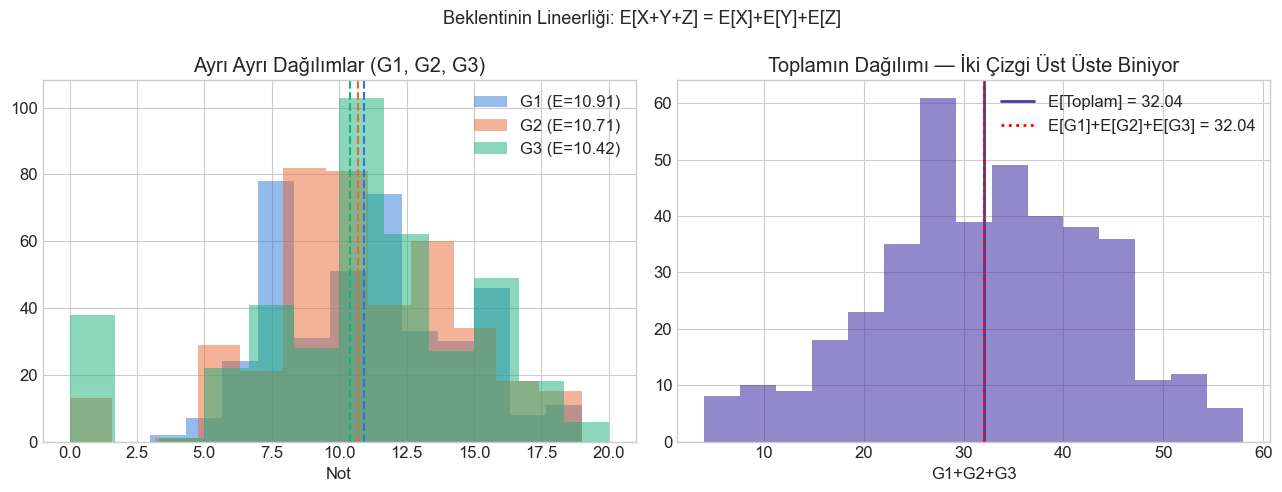

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = {'G1': '#2a78d6', 'G2': '#eb6834', 'G3': '#1baf7a'}

for col in ['G1', 'G2', 'G3']:
    axes[0].hist(
        student[col],
        bins=12,
        alpha=0.5,
        color=colors[col],
        label=f"{col} (E={student[col].mean():.2f})"
    )
    axes[0].axvline(
        student[col].mean(),
        color=colors[col],
        linestyle='--',
        linewidth=1.5
    )

axes[0].set_title("Ayrı Ayrı Dağılımlar (G1, G2, G3)")
axes[0].set_xlabel("Not")
axes[0].legend()

axes[1].hist(total_score, bins=15, color='#4a3aa7', alpha=0.6)

axes[1].axvline(
    E_total,
    color='#4a3aa7',
    linestyle='-',
    linewidth=2,
    label=f"E[Toplam] = {E_total:.2f}"
)

axes[1].axvline(
    sum_of_E,
    color='red',
    linestyle=':',
    linewidth=2,
    label=f"E[G1]+E[G2]+E[G3] = {sum_of_E:.2f}"
)

axes[1].set_title("Toplamın Dağılımı — İki Çizgi Üst Üste Biniyor")
axes[1].set_xlabel("G1+G2+G3")
axes[1].legend()

plt.suptitle(
    "Beklentinin Lineerliği: E[X+Y+Z] = E[X]+E[Y]+E[Z]",
    fontsize=13
)

plt.tight_layout()
plt.show()

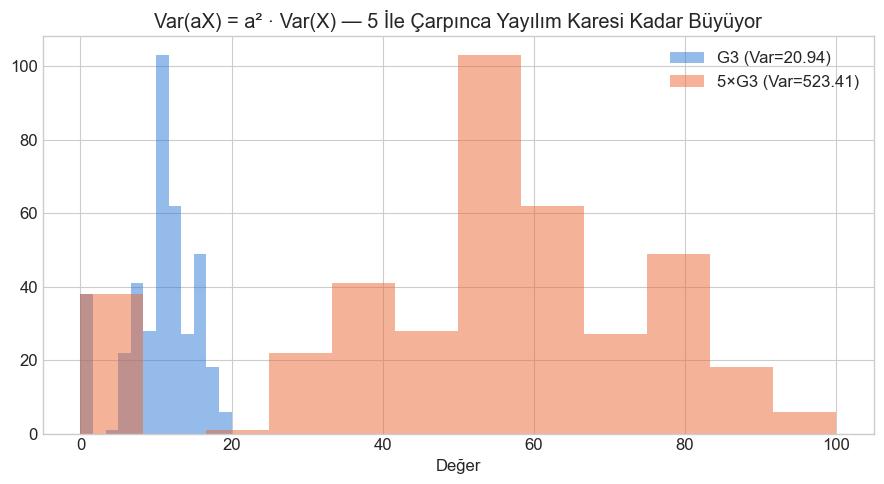

In [7]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    student['G3'],
    bins=12,
    alpha=0.5,
    color='#2a78d6',
    label=f"G3 (Var={student['G3'].var(ddof=0):.2f})"
)

ax.hist(
    G3_100,
    bins=12,
    alpha=0.5,
    color='#eb6834',
    label=f"5×G3 (Var={G3_100.var(ddof=0):.2f})"
)

ax.set_title(
    "Var(aX) = a² · Var(X) — 5 İle Çarpınca Yayılım Karesi Kadar Büyüyor"
)

ax.set_xlabel("Değer")
ax.legend()

plt.tight_layout()
plt.show()

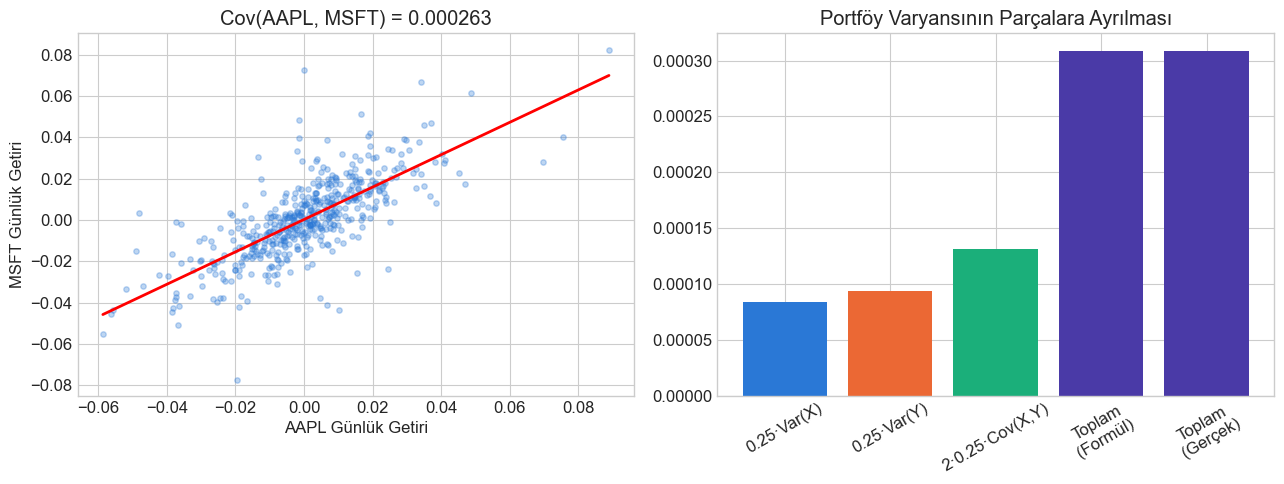

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

returns = data.pct_change().dropna()

X = returns['AAPL']
Y = returns['MSFT']

axes[0].scatter(X, Y, alpha=0.3, s=15, color='#2a78d6')

axes[0].set_xlabel("AAPL Günlük Getiri")
axes[0].set_ylabel("MSFT Günlük Getiri")

axes[0].set_title(f"Cov(AAPL, MSFT) = {Cov_XY:.6f}")

z = np.polyfit(X, Y, 1)
xs = np.linspace(X.min(), X.max(), 100)

axes[0].plot(xs, np.polyval(z, xs), color='red', linewidth=2)

terms = [
    '0.25·Var(X)',
    '0.25·Var(Y)',
    '2·0.25·Cov(X,Y)',
    'Toplam\n(Formül)',
    'Toplam\n(Gerçek)'
]

values = [
    0.25 * Var_X,
    0.25 * Var_Y,
    0.5 * Cov_XY,
    Formula_Var,
    Var_Port
]

colors_bar = [
    '#2a78d6',
    '#eb6834',
    '#1baf7a',
    '#4a3aa7',
    '#4a3aa7'
]

axes[1].bar(terms, values, color=colors_bar)

axes[1].set_title("Portföy Varyansının Parçalara Ayrılması")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

   k  Gerçek (Empirik)  Chebyshev Alt Sınırı  Normal Dağılım Teorik
0  1            0.6987                0.0000                 0.6827
1  2            0.9013                0.7500                 0.9545
2  3            1.0000                0.8889                 0.9973


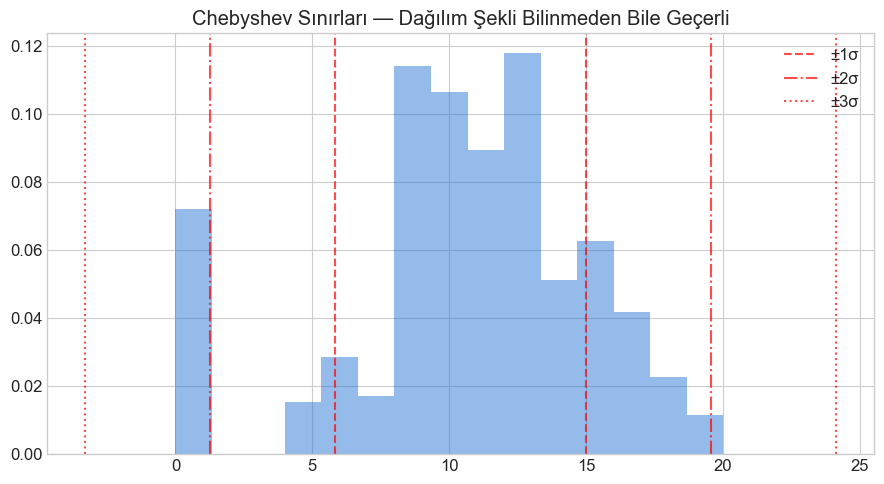

In [9]:
from scipy import stats

data_col = student['G3']

mu = data_col.mean() 
sigma = data_col.std(ddof=0)

ks = [1, 2, 3]
rows = []

for k in ks:

    # Empirik Olarak ±kσ Arasında Kaç Veri Var?
    empirical = np.mean(np.abs(data_col - mu) <= k * sigma)
    # k standart sapma aralığında kalan veri oranı, yani ±kσ aralığında kaç veri olduğunu hesaplıyoruz.
    chebyshev_min = 1 - 1 / k**2
    # CDF (Cumulative Distribution Function) kullanarak normal dağılımın teorik olarak ±kσ aralığında kalan veri oranını hesaplıyoruz.
    normal_theoretical = stats.norm.cdf(k) - stats.norm.cdf(-k)

    rows.append([
        k,
        empirical,
        chebyshev_min,
        normal_theoretical
    ])

cheb_df = pd.DataFrame(
    rows,
    columns=[
        'k',
        'Gerçek (Empirik)', # Gerçek verilerden hesaplanan ±kσ aralığında kalan veri oranı
        'Chebyshev Alt Sınırı', # Chebyshev teoremi ile elde edilen alt sınır
        'Normal Dağılım Teorik' # CDF kullanılarak hesaplanan ±kσ aralığında kalan veri oranı
    ]
)

print(cheb_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    data_col,
    bins=15,
    color='#2a78d6',
    alpha=0.5,
    density=True
)

for k, style in zip(ks, ['--', '-.', ':']):

    ax.axvline(mu - k * sigma, color='red', linestyle=style, alpha=0.7)

    ax.axvline(
        mu + k * sigma,
        color='red',
        linestyle=style,
        alpha=0.7,
        label=f"±{k}σ"
    )

ax.set_title(
    "Chebyshev Sınırları — Dağılım Şekli Bilinmeden Bile Geçerli"
)

ax.legend()

plt.tight_layout()
plt.show()

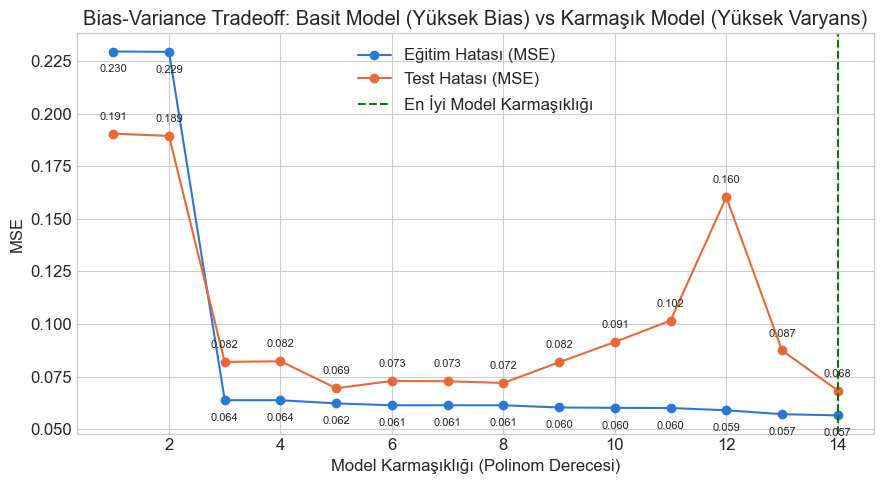

In [16]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# Uniform olarak 120 nokta seçiyoruz ve bunları sıralıyoruz. Bu, x ekseninde eşit aralıklı noktalar oluşturur.
x_true = np.sort(rng.uniform(0, 1, 120))

# Bu noktaların y değerlerini sinüs fonksiyonu ile belirliyoruz ve biraz gürültü ekliyoruz.
y_true = np.sin(2 * np.pi * x_true) + rng.normal(0, 0.25, size=120)

X_train, X_test, y_train, y_test = train_test_split(
    x_true.reshape(-1, 1),
    y_true,
    test_size=0.3,
    random_state=42
)

# Değişik polinom derecelerini test etmek için bir döngü oluşturuyoruz. 
degrees = range(1, 15)

train_errors = []
test_errors = []

for d in degrees:

    model = make_pipeline(
        PolynomialFeatures(d), # Polinom derecesi d olan özellikler oluşturuyoruz
        LinearRegression()    
    )

    model.fit(X_train, y_train)

    train_errors.append(
        np.mean((model.predict(X_train) - y_train) ** 2) # Eğitim hatası (MSE)
    )

    test_errors.append(
        np.mean((model.predict(X_test) - y_test) ** 2) # Test hatası (MSE)
    )

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    degrees,
    train_errors,
    marker='o',
    color='#2a78d6',
    label='Eğitim Hatası (MSE)'
)

ax.plot(
    degrees,
    test_errors,
    marker='o',
    color='#eb6834',
    label='Test Hatası (MSE)'
)

best_degree = list(degrees)[int(np.argmin(test_errors))]

ax.axvline(
    best_degree,
    color='green',
    linestyle='--',
    label='En İyi Model Karmaşıklığı'
)

ax.set_xlabel("Model Karmaşıklığı (Polinom Derecesi)")
ax.set_ylabel("MSE")

ax.set_title(
    "Bias-Variance Tradeoff: Basit Model (Yüksek Bias) vs Karmaşık Model (Yüksek Varyans)"
)

for i, txt in enumerate(test_errors):
    ax.annotate(f"{txt:.3f}", (degrees[i], test_errors[i]), textcoords="offset points", xytext=(0,10), ha='center', fontsize=8)
for i, txt in enumerate(train_errors):
    ax.annotate(f"{txt:.3f}", (degrees[i], train_errors[i]), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=8)

ax.legend()

plt.tight_layout()
plt.show()

---
# 📊 R Uygulaması

R'da formüllerin nasıl doğrulandığına base-R ile bakalım.

In [17]:
%load_ext rpy2.ipython


The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [18]:
%%R -i student

print("R ile Varyans Sabit Carpan Kontrolu")
var_orijinal <- var(student$G1)
var_10_kati <- var(student$G1 * 10)

cat("Orijinal Varyans: ", var_orijinal, "\n")
cat("10 Kati Alinmis: ", var_10_kati, "\n")
cat("Orijinalin 100 kati: ", var_orijinal * 100, "\n")
print("Eşitlik R'da da ispatlandı!")


[1] "R ile Varyans Sabit Carpan Kontrolu"
Orijinal Varyans:  11.01705 
10 Kati Alinmis:  1101.705 
Orijinalin 100 kati:  1101.705 
[1] "Eşitlik R'da da ispatlandı!"


---
# 🗄️ SQL Uygulaması (DuckDB): Toplamın Varyansından Kovaryansı Çekmek!

Eğer veritabanınızda `COVAR_POP` fonksiyonu yoksa ama `VAR_POP` varsa, $Var(X+Y) = Var(X) + Var(Y) + 2Cov(X,Y)$ sihirli formülünü tersine çevirerek Kovaryansı SQL'de bulabilirsiniz:

$$Cov(X,Y) = \frac{Var(X+Y) - Var(X) - Var(Y)}{2}$$

In [19]:
import duckdb
con = duckdb.connect()
con.register('student_tbl', student)
print('DuckDB hazir ✓')


DuckDB hazir ✓


In [20]:
sql_query = """
SELECT 
    ROUND(VAR_POP(G1 + G2), 4) AS Var_Toplam,
    ROUND(VAR_POP(G1), 4) AS Var_G1,
    ROUND(VAR_POP(G2), 4) AS Var_G2,
    
    -- Formül ile çekilen Kovaryans:
    ROUND((VAR_POP(G1 + G2) - VAR_POP(G1) - VAR_POP(G2)) / 2, 4) AS Formul_Cov,
    
    -- Gerçek Kovaryans Fonksiyonu:
    ROUND(COVAR_POP(G1, G2), 4) AS Gercek_Cov
FROM student_tbl;
"""

df_sql = con.execute(sql_query).df()
print(df_sql.T)

print("\nYORUM: Formül ile üretilen Kovaryans, fonksiyonun kendisine BİREBİR eşit! Beklenti ve varyans cebiri her yerde geçerlidir.")


                  0
Var_Toplam  46.3261
Var_G1      10.9892
Var_G2      14.1131
Formul_Cov  10.6119
Gercek_Cov  10.6119

YORUM: Formül ile üretilen Kovaryans, fonksiyonun kendisine BİREBİR eşit! Beklenti ve varyans cebiri her yerde geçerlidir.


## ✏️ Egzersizler 

### E1 — Öğrenci Verisi: Lineerlik
a) `student` veri setinde bir öğrencinin nihai notu `Final = 0.2*G1 + 0.3*G2 + 0.5*G3` formülü ile hesaplanıyor olsun. Python'da $E[Final]$ değerini iki yöntemle bul:
1) Önce her öğrenci için `Final` kolonunu yaratıp `.mean()` alarak.
2) Sadece $0.2*E[G1] + 0.3*E[G2] + 0.5*E[G3]$ formülüyle (Lineerlik kullanarak).
İki sonucun tamamen aynı olduğunu göster.

b) Varyans için aynı şeyi dene: $Var(0.2*G1 + 0.3*G2 + 0.5*G3)$ değerini önce kolon oluşturarak hesapla. Sonra bu değerin $0.2^2*Var(G1) + 0.3^2*Var(G2) + 0.5^2*Var(G3)$ değerine EŞİT OLMADIĞINI göster. Neden eşit olmadıklarını açıkla 

In [24]:
print("\n ==== Egzersiz 1a: Beklentinin Lineerliği ve Ağırlıklı Ortalama ====")
student['Final'] = 0.2 * student['G1'] + 0.3 * student['G2'] + 0.5 * student['G3']
E_final = student['Final'].mean()

E_G1 = student['G1'].mean()
E_G2 = student['G2'].mean()
E_G3 = student['G3'].mean()
sum_of_E = 0.2 * E_G1 + 0.3 * E_G2 + 0.5 * E_G3

print("\n--- BEKLENTİNİN LİNEERLİĞİ (Ağırlıklı Ortalama) ---")
print(f"E[Final] = {E_final:.4f}")
print(f"0.2*E[G1] + 0.3*E[G2] + 0.5*E[G3] = {sum_of_E:.4f}")
print("(Tamamen Eşit! Ağırlıklı ortalama, ağırlıkların çarpımı ile ortalamaların toplamına eşittir.)")

print("\n ==== Egzersiz 1b: Varyansın Sabit Çarpan Kuralı ve Kovaryans ====")

V_final = student['Final'].var(ddof=0)

G1_0_2 = student['G1'] * 0.2
G2_0_3 = student['G2'] * 0.3
G3_0_5 = student['G3'] * 0.5

V_G1_0_2 = G1_0_2.var(ddof=0)
V_G2_0_3 = G2_0_3.var(ddof=0)
V_G3_0_5 = G3_0_5.var(ddof=0)

V_G1_G2 = G1_0_2.cov(G2_0_3)
V_G1_G3 = G1_0_2.cov(G3_0_5)
V_G2_G3 = G2_0_3.cov(G3_0_5)

print("\n--- VARYANSIN KURALI (Ağırlıklı Ortalama) ---")
print(f"Var(Final) = {V_final:.4f}")
print(f"Var(0.2*G1) + Var(0.3*G2) + Var(0.5*G3) = {V_G1_0_2 + V_G2_0_3 + V_G3_0_5:.4f}")
print(f"Cov(0.2*G1, 0.3*G2) = {V_G1_G2:.4f}")
print(f"Cov(0.2*G1, 0.5*G3) = {V_G1_G3:.4f}")
print(f"Cov(0.3*G2, 0.5*G3) = {V_G2_G3:.4f}")
print("Eşitlik sağlanmaz çünkü G1, G2 ve G3 arasında kovaryans vardır. Varyansın toplamı, sadece bağımsız değişkenler için geçerlidir.")


 ==== Egzersiz 1a: Beklentinin Lineerliği ve Ağırlıklı Ortalama ====

--- BEKLENTİNİN LİNEERLİĞİ (Ağırlıklı Ortalama) ---
E[Final] = 10.6035
0.2*E[G1] + 0.3*E[G2] + 0.5*E[G3] = 10.6035
(Tamamen Eşit! Ağırlıklı ortalama, ağırlıkların çarpımı ile ortalamaların toplamına eşittir.)

 ==== Egzersiz 1b: Varyansın Sabit Çarpan Kuralı ve Kovaryans ====

--- VARYANSIN KURALI (Ağırlıklı Ortalama) ---
Var(Final) = 15.3149
Var(0.2*G1) + Var(0.3*G2) + Var(0.5*G3) = 6.9439
Cov(0.2*G1, 0.3*G2) = 0.6383
Cov(0.2*G1, 0.5*G3) = 1.2188
Cov(0.3*G2, 0.5*G3) = 2.3391
Eşitlik sağlanmaz çünkü G1, G2 ve G3 arasında kovaryans vardır. Varyansın toplamı, sadece bağımsız değişkenler için geçerlidir.


---
### E2 — Finans Portföy Varyansı
a) `yfinance` kullanarak `MSFT` ve `TSLA` (Tesla) hisselerinin son 2 yıllık günlük getirilerini çek. Hangi hissenin Marjinal Varyansı (yani tek başına riski) daha yüksek? 

b) %50 MSFT, %50 TSLA içeren bir portföy yap. Bu portföyün varyansı, MSFT'nin tek başına olan varyansından daha mı düşüktür? Nedenini kovaryans matrisi ve çeşitlendirme kuralıyla izah et.

In [30]:
print("\n ==== Egzersiz 2a: Portföy Varyansı ve Kovaryans ====")

print("Yfinance üzerinden son 2 yilin verisi indiriliyor...")
data = yf.download("MSFT TSLA", start="2022-01-01", end="2024-01-01", progress=False)['Close']

returns = data.pct_change().dropna()

X = returns['MSFT']
Y = returns['TSLA']

X_var = X.var()
Y_var = Y.var()
Cov_XY = X.cov(Y)

print("\n--- PORTFÖY VARYANSI HESABI (MSFT ve TSLA) ---")
print(f"Var(MSFT) = {X_var:.6f}")
print(f"Var(TSLA) = {Y_var:.6f}")
print(f"Cov(MSFT, TSLA) = {Cov_XY:.6f}")

print("\n ==== Egzersiz 2b: Portföy Varyansı Formülü ====")

Portfolio = 0.5 * X + 0.5 * Y
Var_Portfolio = Portfolio.var()

print(f"Var(0.5*MSFT + 0.5*TSLA) = {Var_Portfolio:.6f}")



 ==== Egzersiz 2a: Portföy Varyansı ve Kovaryans ====
Yfinance üzerinden son 2 yilin verisi indiriliyor...

--- PORTFÖY VARYANSI HESABI (MSFT ve TSLA) ---
Var(MSFT) = 0.000375
Var(TSLA) = 0.001437
Cov(MSFT, TSLA) = 0.000347

 ==== Egzersiz 2b: Portföy Varyansı Formülü ====
Var(0.5*MSFT + 0.5*TSLA) = 0.000626


---
### E3 — Makine Öğrenmesinde Hata Beklentisi (California)
a) Hata Fonksiyonunun kuralı gereği: $E[(X - c)^2]$ ifadesi, $c = E[X]$ olduğunda MİNİMUM değerini alır. California Housing verisinde `MedHouseVal`'i (Fiyatı) tahmin edeceğiz ama elimizde HİÇBİR X değişkeni (feature) yok. Her ev için aynı sabit tahmini (`c`) yapsaydın, Mean Squared Error (MSE) değerini en aza indirmek için bu sabit sayı ne olmalıydı?

b) O bulduğun en iyi sabit sayıyı ($c = E[Y]$) kullanarak oluşan MSE'yi hesapla. Bu bulduğun MSE, aslında fiyatların ($Y$) **nesidir**? (İpucu: Var(Y) formülünü düşün).

In [36]:
print("\n ==== Egzersiz 3a: X değişkensiz en iyi sabit tahmin ====")

cali = fetch_california_housing()
df = pd.DataFrame(cali.data, columns=cali.feature_names)

Y = cali.target # Gercek fiyatlar

# X değişkenimiz yok.
# Hiçbir feature kullanmadan MSE açısından yapılabilecek en iyi sabit tahmin, tüm evlerin ortalama fiyatıdır.

c = Y.mean() # Ortalama fiyat
Y_hat = np.full_like(Y, c)  # Her ev için aynı tahmin

print(f"Optimal sabit tahmin c = E[Y] = {c:.4f}")


print("\n ==== Egzersiz 3b: MSE Hesaplama ---")
Error = Y - Y_hat
E_error = Error.mean()
MSE = (Error ** 2).mean()



print(f"Hataların Ortalaması E[Error] = {E_error:.8f}")

print(f"Ortalama Hata Karesi E[Error²] (MSE) = {MSE:.4f}")


 ==== Egzersiz 3a: X değişkensiz en iyi sabit tahmin ====
Optimal sabit tahmin c = E[Y] = 2.0686

 ==== Egzersiz 3b: MSE Hesaplama ---
Hataların Ortalaması E[Error] = -0.00000000
Ortalama Hata Karesi E[Error²] (MSE) = 1.3316


---
### E4 — Z-Score (Standartlaştırma) Geometrisi
a) `student` verisinde `G3` notunu Z-Score ile standartlaştır: `Z = (G3 - E[G3]) / Std(G3)`.
Oluşturduğun bu yeni `Z` kolonunun ortalamasının 0, varyansının 1 olduğunu Python ile kanıtla.

b) SQL'de aynı işlemi yap: `G3` notu için Z-score hesapla ve tüm tablo üzerinden hesaplanan Z-skorların ortalamasının (AVG) $\approx 0$, Varyansının (VAR_POP) $\approx 1$ olduğunu gösteren bir sorgu yaz.

In [52]:
print("\n ==== Egzersiz 4a: Z-Score ====")
Z_G3 = (student['G3'] - student['G3'].mean()) / student['G3'].std(ddof=0)

print("Z-Score for G3 (mean) = ", round(Z_G3.mean(), 4))
print("Z-Score for G3 (var) = ", round(Z_G3.var(ddof=0), 4))

print("\n ==== Egzersiz 4b: Z-Score ile Normal Dağılım ====")

sql_z = con.execute("""
    SELECT
        G3,
        ROUND(G3 - AVG(G3) OVER () / STDDEV_POP(G3) OVER (), 4) AS Z_Score
    FROM student_tbl
    GROUP BY G3
""").df()

z_mean = sql_z['Z_Score'].mean()
z_var = sql_z['Z_Score'].var(ddof=0)

print(sql_z.head())
print("Z-Score for G3 (mean) = ", round(z_mean, 4))
print("Z-Score for G3 (var) = ", round(z_var, 4))


 ==== Egzersiz 4a: Z-Score ====
Z-Score for G3 (mean) =  -0.0
Z-Score for G3 (var) =  1.0

 ==== Egzersiz 4b: Z-Score ile Normal Dağılım ====
   G3  Z_Score
0  11   8.9384
1  16  13.9384
2   0  -2.0616
3  15  12.9384
4   9   6.9384
Z-Score for G3 (mean) =  9.2717
Z-Score for G3 (var) =  30.2222
